In [18]:
import os
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [19]:
def load_and_preprocess_images(base_data_dir, subject_id, exclude_test_image=False, test_image_name_pattern=""):
    """
    Loads GIF images for a given subject from a flattened directory, downsamples them, and vectorizes them.
    Assumes filenames are like 'subjectXX.YYY.gif' or 'subjectXX-test.gif'.
    Optionally excludes a specified test image pattern.
    """
    image_list = []
    # All images are in base_data_dir, e.g., 'data/yalefaces/image'
    
    # Define patterns to identify images for the current subject
    subject_prefix = f"subject{subject_id:02d}"
    
    print(f"Loading images for {subject_prefix} from {base_data_dir}...")

    # Collect all relevant files first
    subject_files = []
    if not os.path.exists(base_data_dir):
        print(f"Warning: Directory {base_data_dir} not found. Please ensure your data/yalefaces/image structure is correct.")
        return np.array([])

    for filename in sorted(os.listdir(base_data_dir)):
        if filename.endswith('.gif') and filename.startswith(subject_prefix):
            if exclude_test_image and test_image_name_pattern in filename:
                print(f"Excluding {filename} from training data for {subject_prefix}.")
                continue
            subject_files.append(filename)

    if not subject_files:
        print(f"No GIF images found or processed for {subject_prefix} in {base_data_dir}.")
        return np.array([])

    for filename in subject_files:
        filepath = os.path.join(base_data_dir, filename)
        try:
            img = Image.open(filepath).convert('L') # Convert to grayscale
            # Downsample by a factor of 4
            original_width, original_height = img.size
            new_width = original_width // 4
            new_height = original_height // 4
            img_downsampled = img.resize((new_width, new_height), Image.Resampling.LANCZOS) # Use LANCZOS for high-quality downsampling

            # Vectorize the image
            image_vector = np.array(img_downsampled).flatten()
            image_list.append(image_vector)
        except Exception as e:
            print(f"Error processing {filepath}: {e}")
            continue

    return np.array(image_list)

def visualize_eigenfaces(eigenvectors, original_shape, num_eigenfaces=6, title="Eigenfaces"):
    """
    Visualizes the top N eigenfaces.
    """
    plt.figure(figsize=(num_eigenfaces * 2, 3))
    plt.suptitle(title, fontsize=16)
    for i in range(min(num_eigenfaces, eigenvectors.shape[0])):
        ax = plt.subplot(1, num_eigenfaces, i + 1)
        eigenface = eigenvectors[i].reshape(original_shape)
        ax.imshow(eigenface, cmap='gray')
        ax.axis('off')
        ax.set_title(f'Eigenface {i+1}')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

print("Helper functions defined.")

Helper functions defined.


Processing Subject 1 data from data/yalefaces/...
Loading images for subject01 from data/yalefaces/...
Excluding subject01-test.gif from training data for subject01.
Shape of Subject 1 training data: (10, 4800)


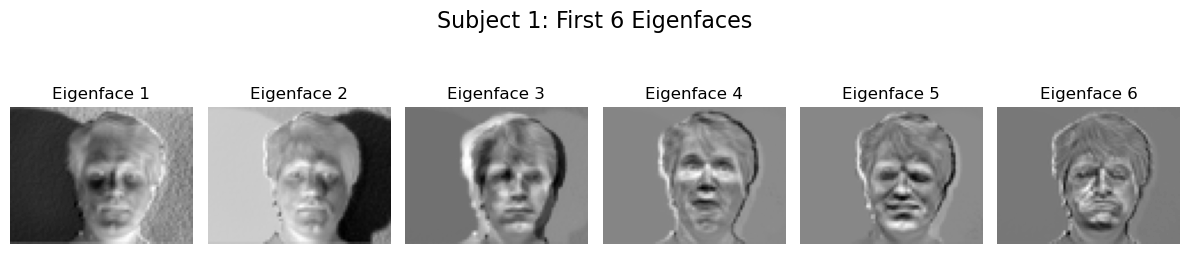

In [20]:
base_data_dir = 'data/yalefaces/' # Updated path based on your structure
subject1_test_image_name_pattern = 'subject01-test.gif' # Pattern to match the test image filename

print(f"Processing Subject 1 data from {base_data_dir}...")
subject1_train_data = load_and_preprocess_images(
    base_data_dir=base_data_dir,
    subject_id=1,
    exclude_test_image=True,
    test_image_name_pattern=subject1_test_image_name_pattern
)

if subject1_train_data.size > 0:
    print(f"Shape of Subject 1 training data: {subject1_train_data.shape}")

    # Perform PCA
    pca_subject1 = PCA()
    pca_subject1.fit(subject1_train_data)

    # Get the original image shape for visualization (downsampled size)
    # We need to load one image to get its dimensions.
    # Pick the first non-test image for subject01 if available.
    temp_img_file = None
    for filename in sorted(os.listdir(base_data_dir)):
        if filename.startswith('subject01') and filename.endswith('.gif') and filename != subject1_test_image_name_pattern:
            temp_img_file = filename
            break
    
    if temp_img_file:
        temp_img_path = os.path.join(base_data_dir, temp_img_file)
        temp_img = Image.open(temp_img_path).convert('L')
        original_width, original_height = temp_img.size
        downsampled_shape = (original_height // 4, original_width // 4) # (height, width)
        
        # Plot the first 6 eigenfaces for Subject 1
        visualize_eigenfaces(pca_subject1.components_[:6], downsampled_shape, num_eigenfaces=6, title='Subject 1: First 6 Eigenfaces')
    else:
        print("Could not find a training image for Subject 1 to determine downsampled shape for visualization.")
else:
    print("Subject 1 training data could not be loaded or processed. Skipping PCA for Subject 1.")


Processing Subject 2 data from data/yalefaces/...
Loading images for subject02 from data/yalefaces/...
Excluding subject02-test.gif from training data for subject02.
Shape of Subject 2 training data: (9, 4800)


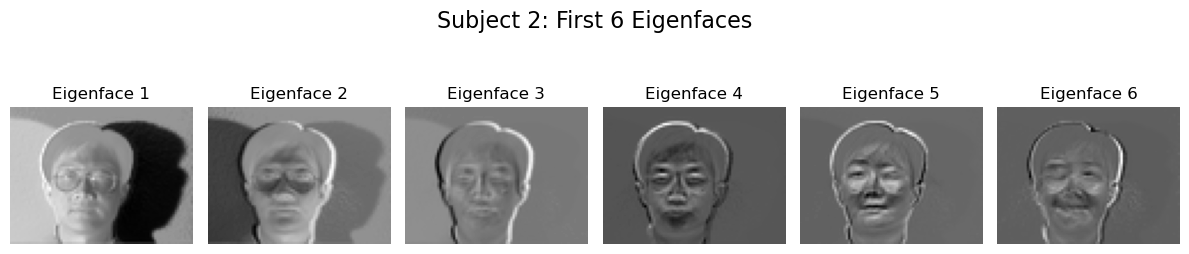

In [21]:
subject2_test_image_name_pattern = 'subject02-test.gif' # Pattern to match the test image filename

print(f"\nProcessing Subject 2 data from {base_data_dir}...")
subject2_train_data = load_and_preprocess_images(
    base_data_dir=base_data_dir,
    subject_id=2,
    exclude_test_image=True,
    test_image_name_pattern=subject2_test_image_name_pattern
)

if subject2_train_data.size > 0:
    print(f"Shape of Subject 2 training data: {subject2_train_data.shape}")

    # Perform PCA
    pca_subject2 = PCA()
    pca_subject2.fit(subject2_train_data)

    # Get the original image shape for visualization (downsampled size)
    # Pick the first non-test image for subject02 if available.
    temp_img_file = None
    for filename in sorted(os.listdir(base_data_dir)):
        if filename.startswith('subject02') and filename.endswith('.gif') and filename != subject2_test_image_name_pattern:
            temp_img_file = filename
            break

    if temp_img_file:
        temp_img_path = os.path.join(base_data_dir, temp_img_file)
        temp_img = Image.open(temp_img_path).convert('L')
        original_width, original_height = temp_img.size
        downsampled_shape = (original_height // 4, original_width // 4) # (height, width)

        # Plot the first 6 eigenfaces for Subject 2
        visualize_eigenfaces(pca_subject2.components_[:6], downsampled_shape, num_eigenfaces=6, title='Subject 2: First 6 Eigenfaces')
    else:
        print("Could not find a training image for Subject 2 to determine downsampled shape for visualization.")
else:
    print("Subject 2 training data could not be loaded or processed. Skipping PCA for Subject 2.")

In [22]:
print("\n--- Explanation of Eigenface Patterns (Question 1) ---")
print("""
Typically, for the top eigenfaces (principal components), you might observe:
- **First Eigenface:** Often resembles the 'average' face of the dataset, capturing the most significant variations. It might appear blurry but captures the general shape and lighting.
- **Subsequent Eigenfaces:** Tend to capture specific variations such as:
    - **Lighting variations:** Different directions of light across the face (e.g., one side brighter than the other).
    - **Facial expressions:** Subtle changes around the eyes, mouth, or eyebrows.
    - **Head pose:** Slight rotations or tilts of the head.
    - **Distinct features:** Features that vary significantly among individuals within the dataset (e.g., spectacles, hair variations).

The patterns represent the fundamental modes of variation in the face images for that particular subject.
""")


--- Explanation of Eigenface Patterns (Question 1) ---

Typically, for the top eigenfaces (principal components), you might observe:
- **First Eigenface:** Often resembles the 'average' face of the dataset, capturing the most significant variations. It might appear blurry but captures the general shape and lighting.
- **Subsequent Eigenfaces:** Tend to capture specific variations such as:
    - **Lighting variations:** Different directions of light across the face (e.g., one side brighter than the other).
    - **Facial expressions:** Subtle changes around the eyes, mouth, or eyebrows.
    - **Head pose:** Slight rotations or tilts of the head.
    - **Distinct features:** Features that vary significantly among individuals within the dataset (e.g., spectacles, hair variations).

The patterns represent the fundamental modes of variation in the face images for that particular subject.



In [23]:
print("\n--- Face Recognition Task (Question 2) ---")

# Load and preprocess test images
# Test images are also expected to be in base_data_dir
subject01_test_img_path = os.path.join(base_data_dir, subject1_test_image_name_pattern)
subject02_test_img_path = os.path.join(base_data_dir, subject2_test_image_name_pattern)

test_image_s1_vector = None
test_image_s2_vector = None

try:
    img_s1_test = Image.open(subject01_test_img_path).convert('L')
    original_width, original_height = img_s1_test.size
    new_width = original_width // 4
    new_height = original_height // 4
    img_s1_test_downsampled = img_s1_test.resize((new_width, new_height), Image.Resampling.LANCZOS)
    test_image_s1_vector = np.array(img_s1_test_downsampled).flatten()
    print(f"Loaded and preprocessed {subject1_test_image_name_pattern}. Shape: {test_image_s1_vector.shape}")
except Exception as e:
    print(f"Error loading or processing {subject01_test_img_path}: {e}")

try:
    img_s2_test = Image.open(subject02_test_img_path).convert('L')
    original_width, original_height = img_s2_test.size
    new_width = original_width // 4
    new_height = original_height // 4
    img_s2_test_downsampled = img_s2_test.resize((new_width, new_height), Image.Resampling.LANCZOS)
    test_image_s2_vector = np.array(img_s2_test_downsampled).flatten()
    print(f"Loaded and preprocessed {subject2_test_image_name_pattern}. Shape: {test_image_s2_vector.shape}")
except Exception as e:
    print(f"Error loading or processing {subject02_test_img_path}: {e}")


--- Face Recognition Task (Question 2) ---
Loaded and preprocessed subject01-test.gif. Shape: (4800,)
Loaded and preprocessed subject02-test.gif. Shape: (4800,)


In [24]:
s_scores = {}

# Ensure PCA models were successfully trained and test images loaded
if 'pca_subject1' in locals() and 'pca_subject2' in locals() and \
   test_image_s1_vector is not None and test_image_s2_vector is not None:

    # --- Calculations for test_image_s1 ---
    if pca_subject1.components_.shape[0] > 0:
        eigenfaces_s1 = pca_subject1.components_
        mean_s1 = pca_subject1.mean_
        centered_test_image_s1 = test_image_s1_vector - mean_s1
        # Project into Subject 1's eigenface space and reconstruct
        weights_s1_s1 = np.dot(centered_test_image_s1, eigenfaces_s1.T)
        reconstructed_s1_from_s1_space = np.dot(weights_s1_s1, eigenfaces_s1) + mean_s1
        s_scores['s11'] = np.linalg.norm(test_image_s1_vector - reconstructed_s1_from_s1_space)**2
    else:
        s_scores['s11'] = np.inf # Cannot calculate if no eigenfaces for Subject 1

    if pca_subject2.components_.shape[0] > 0:
        eigenfaces_s2 = pca_subject2.components_
        mean_s2 = pca_subject2.mean_
        centered_test_image_s1_against_s2_mean = test_image_s1_vector - mean_s2
        # Project into Subject 2's eigenface space and reconstruct
        weights_s1_s2 = np.dot(centered_test_image_s1_against_s2_mean, eigenfaces_s2.T)
        reconstructed_s1_from_s2_space = np.dot(weights_s1_s2, eigenfaces_s2) + mean_s2
        s_scores['s12'] = np.linalg.norm(test_image_s1_vector - reconstructed_s1_from_s2_space)**2
    else:
        s_scores['s12'] = np.inf # Cannot calculate if no eigenfaces for Subject 2

    # --- Calculations for test_image_s2 ---
    if pca_subject1.components_.shape[0] > 0:
        eigenfaces_s1 = pca_subject1.components_
        mean_s1 = pca_subject1.mean_
        centered_test_image_s2_against_s1_mean = test_image_s2_vector - mean_s1
        # Project into Subject 1's eigenface space and reconstruct
        weights_s2_s1 = np.dot(centered_test_image_s2_against_s1_mean, eigenfaces_s1.T)
        reconstructed_s2_from_s1_space = np.dot(weights_s2_s1, eigenfaces_s1) + mean_s1
        s_scores['s21'] = np.linalg.norm(test_image_s2_vector - reconstructed_s2_from_s1_space)**2
    else:
        s_scores['s21'] = np.inf # Cannot calculate if no eigenfaces for Subject 1

    if pca_subject2.components_.shape[0] > 0:
        eigenfaces_s2 = pca_subject2.components_
        mean_s2 = pca_subject2.mean_
        centered_test_image_s2 = test_image_s2_vector - mean_s2
        # Project into Subject 2's eigenface space and reconstruct
        weights_s2_s2 = np.dot(centered_test_image_s2, eigenfaces_s2.T)
        reconstructed_s2_from_s2_space = np.dot(weights_s2_s2, eigenfaces_s2) + mean_s2
        s_scores['s22'] = np.linalg.norm(test_image_s2_vector - reconstructed_s2_from_s2_space)**2
    else:
        s_scores['s22'] = np.inf # Cannot calculate if no eigenfaces for Subject 2

    print("\nReported Scores (s_ij = ||test image_j - reconstructed_from_eigenface_space_i||_2^2):")
    print(f"s_11 (Test Subject 1 vs Eigenfaces Subject 1): {s_scores.get('s11', 'N/A'):.4f}")
    print(f"s_12 (Test Subject 1 vs Eigenfaces Subject 2): {s_scores.get('s12', 'N/A'):.4f}")
    print(f"s_21 (Test Subject 2 vs Eigenfaces Subject 1): {s_scores.get('s21', 'N/A'):.4f}")
    print(f"s_22 (Test Subject 2 vs Eigenfaces Subject 2): {s_scores.get('s22', 'N/A'):.4f}")

    print("\n--- How to Recognize Faces Using These Scores (Question 2) ---")
    print("""
    To recognize the faces of the test images using these scores, we apply the principle that a test image belonging to a particular subject will have a lower projection residual (reconstruction error) when projected onto that subject's eigenface space compared to being projected onto another subject's eigenface space.

    * **For `test image_j`:** Compare `s_j1` (residual with Subject 1's eigenfaces) and `s_j2` (residual with Subject 2's eigenfaces).
    * If `s_j1 < s_j2`, then `test image_j` is likely to be Subject 1.
    * If `s_j2 < s_j1`, then `test image_j` is likely to be Subject 2.

    In essence, the eigenface space of the correct person should be able to reconstruct their image with less error, as it captures the variations inherent to that person's face.
    """)
else:
    print("Cannot perform face recognition. Ensure PCA models were trained and test images loaded successfully.")


Reported Scores (s_ij = ||test image_j - reconstructed_from_eigenface_space_i||_2^2):
s_11 (Test Subject 1 vs Eigenfaces Subject 1): 5663221.1840
s_12 (Test Subject 1 vs Eigenfaces Subject 2): 30345221.7957
s_21 (Test Subject 2 vs Eigenfaces Subject 1): 33678880.1755
s_22 (Test Subject 2 vs Eigenfaces Subject 2): 1924890.8457

--- How to Recognize Faces Using These Scores (Question 2) ---

    To recognize the faces of the test images using these scores, we apply the principle that a test image belonging to a particular subject will have a lower projection residual (reconstruction error) when projected onto that subject's eigenface space compared to being projected onto another subject's eigenface space.

    * **For `test image_j`:** Compare `s_j1` (residual with Subject 1's eigenfaces) and `s_j2` (residual with Subject 2's eigenfaces).
    * If `s_j1 < s_j2`, then `test image_j` is likely to be Subject 1.
    * If `s_j2 < s_j1`, then `test image_j` is likely to be Subject 2.

    In

In [25]:
print("\n--- Discussion on Algorithm Performance and Improvements (Question 3) ---")
print("""
**Comment if your face recognition algorithm works well:**

**How to improve the algorithm if possible:**

1.  **More Data/Subjects:** The Yale Face dataset has more subjects and more images per subject. Training with a larger, more diverse dataset would lead to more robust eigenfaces that generalize better.
2.  **Number of Principal Components (Eigenfaces):** The current approach uses all eigenfaces to define the subspace for reconstruction. Experimenting with different numbers of top eigenfaces (K) (e.g., using a fixed K, or selecting K based on explained variance, e.g., retaining components that explain 95% of variance) can significantly impact performance. Too few might lose important information; too many might capture noise or irrelevant variations.
3.  **Preprocessing Techniques:**
    * **Face Alignment:** Before PCA, aligning faces (e.g., by detecting eyes and rotating/scaling) can reduce variations due to pose and improve consistency.
    * **Illumination Normalization:** Techniques like histogram equalization or gamma correction can reduce the impact of varying lighting conditions.
4.  **Distance Metric:** While Euclidean distance ($L_2$ norm) for reconstruction error is common, other metrics or classification approaches (e.g., k-NN on the projected features) could be explored.
5.  **Fisherfaces (Linear Discriminant Analysis - LDA):** PCA is unsupervised and finds directions of maximum variance. LDA (Fisherfaces) is a supervised method that finds directions that maximize class separability (i.e., maximize between-class variance while minimizing within-class variance). This is often more effective for classification tasks like face recognition when labeled data is available.
6.  **Local Feature Descriptors (e.g., LBP, HOG) with Machine Learning Classifiers:** Instead of global eigenfaces, extracting local features (which are more robust to partial occlusions or local distortions) and training a classifier (like SVM or Random Forest) on these features can be more robust to variations like partial occlusions or expression changes.
7.  **Deep Learning Approaches (e.g., CNNs):** For state-of-the-art face recognition, deep convolutional neural networks (CNNs) have shown superior performance. They can learn highly discriminative features directly from raw pixel data and are much more robust to variations in pose, illumination, and expression.

This simplified eigenface approach provides a foundational understanding but has limitations, especially with significant variations in pose, lighting, or expression not adequately represented in the training set.
""")


--- Discussion on Algorithm Performance and Improvements (Question 3) ---

**Comment if your face recognition algorithm works well:**

**How to improve the algorithm if possible:**

1.  **More Data/Subjects:** The Yale Face dataset has more subjects and more images per subject. Training with a larger, more diverse dataset would lead to more robust eigenfaces that generalize better.
2.  **Number of Principal Components (Eigenfaces):** The current approach uses all eigenfaces to define the subspace for reconstruction. Experimenting with different numbers of top eigenfaces (K) (e.g., using a fixed K, or selecting K based on explained variance, e.g., retaining components that explain 95% of variance) can significantly impact performance. Too few might lose important information; too many might capture noise or irrelevant variations.
3.  **Preprocessing Techniques:**
    * **Face Alignment:** Before PCA, aligning faces (e.g., by detecting eyes and rotating/scaling) can reduce variations du